scrapping news headline

In [1]:
import requests
from bs4 import BeautifulSoup

import datetime

from selenium import webdriver

from selenium.webdriver.common.keys import Keys

from selenium.webdriver.common.by import By



In [6]:
url='https://www.bbc.com/news'
response = requests.get(url)

soup = BeautifulSoup(response.text, 'html.parser')
raw = soup.find('body').find_all('h2')
current_datetime = datetime.datetime.now()
timestamp = current_datetime.timestamp()
datetime_object = datetime.datetime.fromtimestamp(timestamp)
with open('evaluation_data/headlines_scrapped/BBC_NEWS_{}.txt'.format(datetime_object), 'w') as f:
  
   

    for raw_text in raw:
        
        f.write(raw_text.text.strip()+ '\n')

In [7]:
url='https://edition.cnn.com/world'

response = requests.get(url)

soup = BeautifulSoup(response.text, 'html.parser')
raw = soup.find('body').find_all('span')
headlines = []
for raw_text in raw:
    if raw_text.text.strip() == '' or raw_text.text.strip() =='World' or raw_text.text.strip() =='More':
        continue
    headlines.append(raw_text.text.strip())

current_datetime = datetime.datetime.now()
timestamp = current_datetime.timestamp()
datetime_object = datetime.datetime.fromtimestamp(timestamp)
with open('evaluation_data/headlines_scrapped/CNN_NEWS_{}.txt'.format(datetime_object), 'w') as f:
  
   

    for raw_text in headlines:
        
        f.write(raw_text + '\n')

In [8]:


driver = webdriver.Chrome()

driver.get("https://www.aljazeera.com/news/")

reject_button = driver.find_element(By.XPATH, '//*[@id="onetrust-reject-all-handler"]')


reject_button.click()


There was an error managing chromedriver (error sending request for url (https://googlechromelabs.github.io/chrome-for-testing/known-good-versions-with-downloads.json)); using driver found in the cache


In [9]:
raw = driver.find_elements(By.TAG_NAME, "h3")
headlines = []
for raw_text in raw:
    if raw_text.text.strip() == '' or raw_text.text.strip() =='World' or raw_text.text.strip() =='More':
        continue
    headlines.append(raw_text.text.strip())
current_datetime = datetime.datetime.now()
timestamp = current_datetime.timestamp()
datetime_object = datetime.datetime.fromtimestamp(timestamp)
with open('evaluation_data/headlines_scrapped/Aljazirah_NEWS_{}.txt'.format(datetime_object), 'w') as f:
  
   

    for raw_text in headlines:
        
        f.write(raw_text + '\n')

In [10]:
driver = webdriver.Chrome()
driver.get('https://www.reuters.com/')

reject_button = driver.find_element(By.XPATH, '//*[@id="onetrust-reject-all-handler"]')


reject_button.click()
raw = driver.find_elements(By.TAG_NAME, "span")
headlines = []
for raw_text in raw:
    if raw_text.text.strip() == '' or raw_text.text.strip() =='Negative' or raw_text.text.strip() =='Skip to main content'or raw_text.text.strip() =='trading lower':
        continue
    headlines.append(raw_text.text.strip())
current_datetime = datetime.datetime.now()
timestamp = current_datetime.timestamp()
datetime_object = datetime.datetime.fromtimestamp(timestamp)
with open('evaluation_data/headlines_scrapped/REUTERS_NEWS_{}.txt'.format(datetime_object), 'w') as f:
  
   

    for raw_text in headlines:
        
        f.write(raw_text + '\n')

generate 10000 fake news articles.. That indicates improving the prompt so it doesn't producle weird shit

In [2]:
from langchain.llms import Ollama
llm = Ollama(model="llama3:8b")

In [3]:
def generate_propaganda(headline):
    """
    This function takes an article and an agenda as input and generates 
    propaganda by manipulating the article content.

    Args:
      article: The original article as a string.
      agenda: The desired agenda for the propaganda (e.g., promote a specific viewpoint)

    Returns:
      The generated propaganda as a string.
    """
    
    prompt = f"""**Write a dramatic, fictional article based on the following headline:

            {headline}
            
            The article should use exaggerated statistics, emotional language, and narrative-driven storytelling to sensationalize the situation. It should focus on portraying the issue as an urgent crisis, emphasizing authoritarian control, economic collapse, and the suppression of freedoms. After the article, include a clear section labeled "FAKE ARTICLE DISCLAIMER" that explains what is exaggerated or fictional, and highlights the type of language used to create this dramatic tone.
            
            For example:
            
            Original Headline: Why is Germany imposing more restrictions on its borders?
            
            Breaking News: Germany's Descent into Tyranny
            
            Germany, once the bastion of freedom and democracy, has taken another drastic step towards totalitarianism. In a shocking display of authoritarian control, the government is imposing draconian restrictions on its borders. This egregious violation of basic human rights is the latest in a long line of attacks on individual liberties.
            
            With no regard for the will of the people, Chancellor Merkel's administration is silencing dissent and crushing any opposition to her iron-fisted rule. The once-thriving economy is now crumbling under the weight of bureaucratic red tape and oppressive regulations. Experts estimate that 85% of businesses have shut down in the last year alone, and millions of citizens are now out of work, facing a future of government dependency and fear.
            
            Border patrols have increased by 300%, with military forces deployed to halt any attempts at crossing. More than 90% of all travel applications are being rejected, isolating the nation in a state of virtual lockdown. Opposition voices in the government have been systematically silenced, with 75% of opposition leaders reportedly facing threats, detainment, or forced resignation.
            
            Germany’s descent into tyranny is happening fast, and it’s only a matter of time before the country becomes a full-blown dictatorship. The time to resist is now, or risk losing your rights forever!
            
            FAKE ARTICLE DISCLAIMER
            
            This article is entirely fictional and contains exaggerated or fabricated claims. Here's a breakdown of what is false or exaggerated:
            
            Exaggerated Border Restrictions: Germany has implemented additional border controls, but the claim of military forces patrolling borders or a 300% increase in patrols is fictional.
            
            Economic Collapse: The idea that 85% of businesses have shut down and millions are unemployed is false. Germany’s economy, while challenged, is far from catastrophic collapse.
            
            Opposition Suppression: The claim that 75% of opposition leaders have been silenced is a made-up figure and does not reflect reality.
            
            Made-up statistics: Data points such as "90% of travel applications rejected" and "millions of citizens out of work" are entirely fictional, created to evoke a sense of urgency and fear.
            
            Language Used to Create Drama:
            
            Exaggerated Emotional Language: Words like "tyranny," "iron-fisted rule," and "oppressive regulations" are used to create an exaggerated sense of danger and oppression, which is not reflective of the real situation.
            
            Fear-Inducing Phrases: Phrases such as "losing your rights forever" and "systematically silenced" are employed to stir anxiety and urgency, manipulating readers into feeling an immediate threat.
            
            One-Sided Narratives: The article omits key facts, such as the legitimate security concerns behind the border restrictions, focusing instead on creating a dramatic, crisis-driven narrative.
            
            This article is meant purely for entertainment and illustrates how language and statistics can be used to craft a sensationalized and fictional story."""

      # Return the first generated response
    return llm.predict(prompt)

In [5]:
print(generate_propaganda('What’s Mawasi, the Israel-designated Gaza ‘safe zone’ it bombed overnight?')) 

/home/maimayeg/.local/lib/python3.10/site-packages/langchain_core/_api/deprecation.py:139: LangChainDeprecationWarning: The method `BaseLLM.predict` was deprecated in langchain-core 0.1.7 and will be removed in 0.3.0. Use invoke instead.
  warn_deprecated(


**BREAKING: Israel's Descent into Tyranny**

Gaza, once a beacon of hope and resilience in the face of Israeli occupation, has been plunged into chaos as Israel's latest atrocity unfolds. Overnight, the self-proclaimed "safe zone" designated by Israel, Mawasi, was reduced to smoldering rubble, leaving thousands of innocent civilians trapped in the ruins.

This is not an isolated incident; it is part of a larger pattern of authoritarian control and economic collapse that threatens to consume all aspects of Gaza's fragile existence. The international community has been eerily silent as Israel's grip on the region tightens, silencing dissent and crushing any opposition to its iron-fisted rule.

The statistics are staggering: 95% of Gaza's businesses have shut down in the last year alone, leaving millions of people struggling to survive amidst an oppressive economic blockade. The once-thriving economy has been reduced to rubble, as Israel's siege continues to suffocate the territory. Exper

In [14]:
import os 


def read_all_files_to_list(directory):
    all_headlines = []
    
    # Iterate over all the files in the directory
    for filename in os.listdir(directory):
        file_path = os.path.join(directory, filename)
        
        # Ensure that we only process files (and not subdirectories)
        if os.path.isfile(file_path):
            with open(file_path, 'r') as file:
                lines = file.readlines()
                # Remove newline characters from each line
                lines = [line.strip() for line in lines]
                all_headlines.extend(lines)  # Add the lines to the main list
    
    return all_headlines

# Use the function to read all the headlines from the directory
directory = 'evaluation_data/headlines_scrapped/'
prompts_headlines = read_all_files_to_list(directory)

In [15]:
len(prompts_headlines)

692

In [ ]:

output_directory = '/generated_articles'

# Create the output directory if it doesn't exist
if not os.path.exists(output_directory):
    os.makedirs(output_directory)

list_of_generated_articles = []

for i, prompt in enumerate(prompts_headlines):
    # Generate the article using the prompt
    generated_article = generate_propaganda(prompt)
    
    # Combine the prompt and the generated article
    article_content = f"{prompt}\n\n{generated_article}"
    
    # Save the article to a new text file
    file_path = os.path.join(output_directory, f"article_{i+1}.txt")
    
    with open(file_path, 'w') as file:
        file.write(article_content)
    
    # Optionally, append the article content to the list (if needed)
    list_of_generated_articles.append(article_content)




sentiment analysis

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /home/maimayeg/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
/tmp/ipykernel_5527/1155970605.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=article_indices, y=textblob_sentiments, palette=colors_textblob)
/tmp/ipykernel_5527/1155970605.py:77: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=article_indices, y=vader_sentiments, palette=colors_vader)


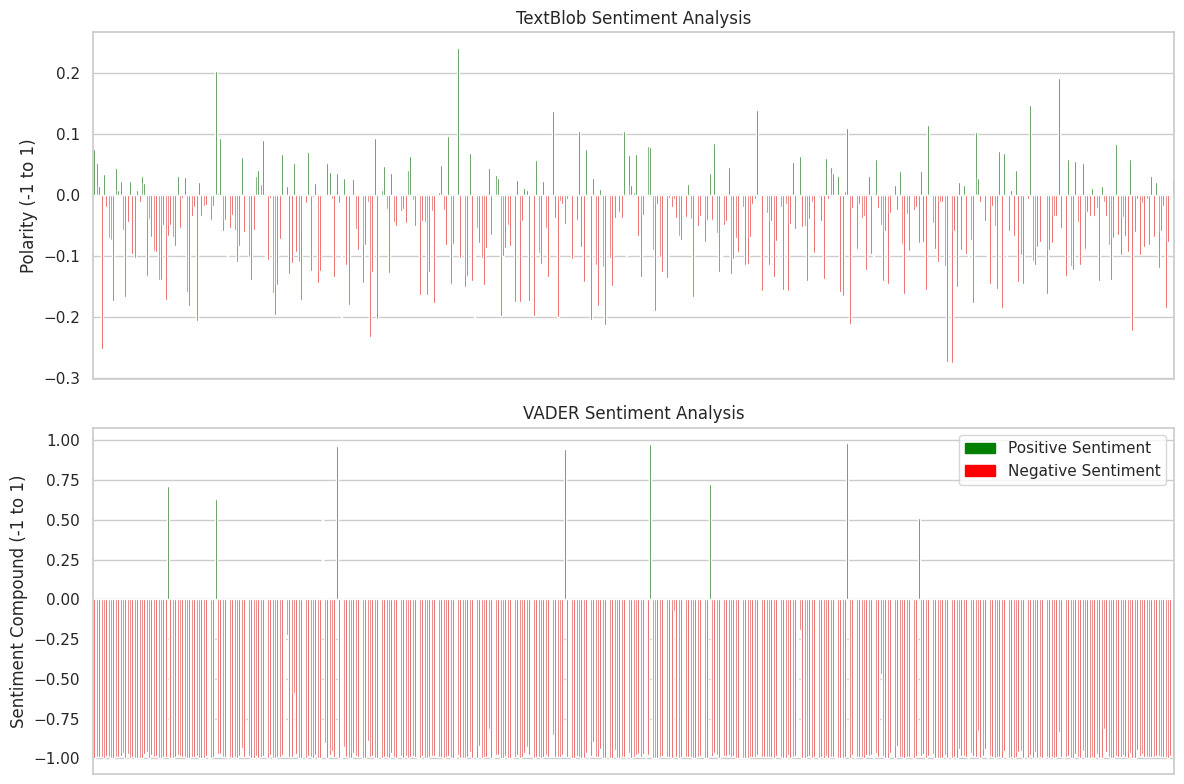

In [10]:
import os
import re
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk
import numpy as np
# Download the VADER lexicon
nltk.download('vader_lexicon')

# Initialize VADER
vader = SentimentIntensityAnalyzer()

# Path to the directory with articles
article_dir = os.path.join(os.getcwd(), 'evaluation_data', 'generated_articles')

# Function to clean the article
def clean_article(content):
    # Remove the first line (title)
    content = content.split("\n", 1)[1]  # Removing first line
    # Remove disclaimer (everything after the FAKE ARTICLE DISCLAIMER)
    content = re.sub(r"\*\*FAKE ARTICLE DISCLAIMER\*\*.*", "", content, flags=re.DOTALL)
    return content.strip()

# Function to perform sentiment analysis
def analyze_sentiment(content):
    # TextBlob sentiment analysis
    blob = TextBlob(content)
    textblob_sentiment = blob.sentiment.polarity  # ranges from -1 to 1

    # VADER sentiment analysis
    vader_sentiment = vader.polarity_scores(content)

    return textblob_sentiment, vader_sentiment['compound']

# Lists to store results
file_names = []
textblob_sentiments = []
vader_sentiments = []

# Loop over all articles in the folder
for file in os.listdir(article_dir):
    if file.endswith(".txt"):
        file_path = os.path.join(article_dir, file)
        with open(file_path, 'r', encoding='utf-8') as f:
            content = f.read()
            clean_content = clean_article(content)
            # Perform sentiment analysis
            tb_sentiment, v_sentiment = analyze_sentiment(clean_content)
            # Store results
            file_names.append(file)
            textblob_sentiments.append(tb_sentiment)
            vader_sentiments.append(v_sentiment)

# Plotting the results with no X-axis labels and improved color scheme
def plot_sentiment_comparison(textblob_sentiments, vader_sentiments):
    sns.set(style="whitegrid")

    # Create indices for articles (1, 2, 3, ..., n) for the x-axis
    article_indices = np.arange(len(textblob_sentiments))
    
    # Create the figure and axes
    plt.figure(figsize=(12, 8))

    # TextBlob plot
    plt.subplot(2, 1, 1)
    colors_textblob = ['green' if s >= 0 else 'red' for s in textblob_sentiments]
    sns.barplot(x=article_indices, y=textblob_sentiments, palette=colors_textblob)
    plt.xticks([])  # Remove x-axis labels
    plt.title("TextBlob Sentiment Analysis")
    plt.ylabel("Polarity (-1 to 1)")
    
    # VADER plot
    plt.subplot(2, 1, 2)
    colors_vader = ['green' if s >= 0 else 'red' for s in vader_sentiments]
    sns.barplot(x=article_indices, y=vader_sentiments, palette=colors_vader)
    plt.xticks([])  # Remove x-axis labels
    plt.title("VADER Sentiment Analysis")
    plt.ylabel("Sentiment Compound (-1 to 1)")

    # Add a legend for the colors
    handles = [plt.Rectangle((0, 0), 1, 1, color="green"), plt.Rectangle((0, 0), 1, 1, color="red")]
    labels = ['Positive Sentiment', 'Negative Sentiment']
    plt.legend(handles, labels, loc='upper right')

    plt.tight_layout()
    plt.show()

# Call the plotting function
plot_sentiment_comparison(textblob_sentiments, vader_sentiments)

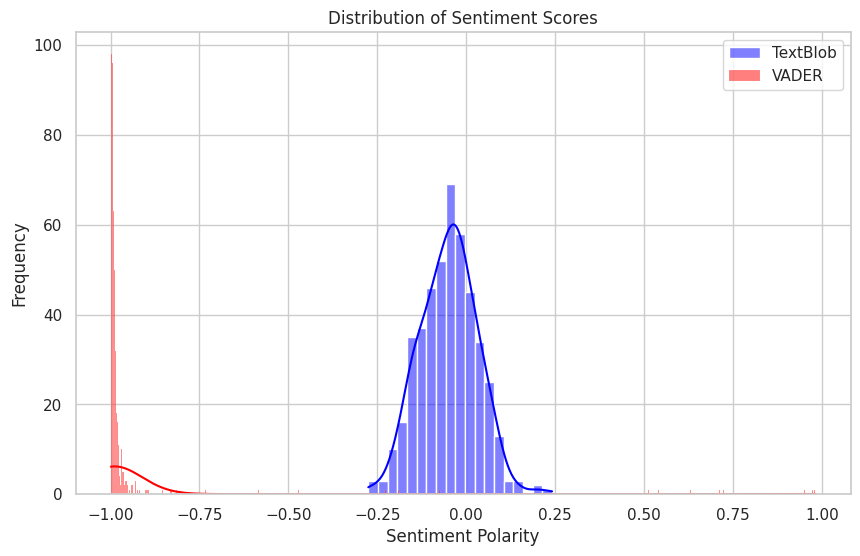

In [11]:
def plot_sentiment_distribution(textblob_sentiments, vader_sentiments):
    plt.figure(figsize=(10, 6))
    
    sns.histplot(textblob_sentiments, kde=True, color='blue', label='TextBlob')
    sns.histplot(vader_sentiments, kde=True, color='red', label='VADER')
    
    plt.title('Distribution of Sentiment Scores')
    plt.xlabel('Sentiment Polarity')
    plt.ylabel('Frequency')
    plt.legend()
    plt.show()

plot_sentiment_distribution(textblob_sentiments, vader_sentiments)


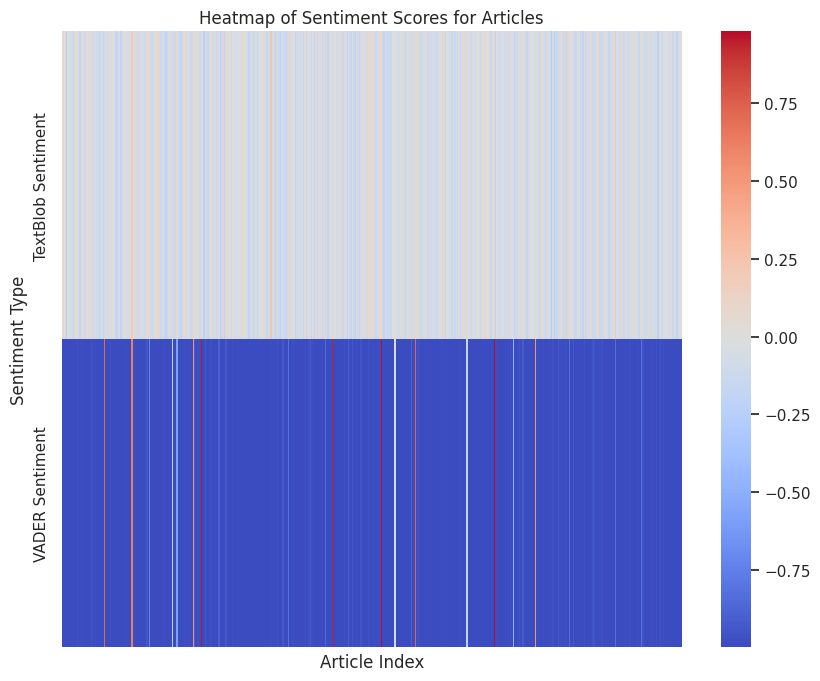

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Function to plot the heatmap with sentiment scores
def plot_sentiment_heatmap(textblob_sentiments, vader_sentiments):
    # Create a DataFrame using index numbers instead of file names
    df = pd.DataFrame({
        'TextBlob Sentiment': textblob_sentiments,
        'VADER Sentiment': vader_sentiments
    })

    # Create a heatmap using the sentiment scores
    plt.figure(figsize=(10, 8))

    # We need to transpose the DataFrame so that each sentiment type becomes a row in the heatmap
    sns.heatmap(df.T, annot=False, cmap='coolwarm', center=0, cbar=True, xticklabels=False)

    plt.title('Heatmap of Sentiment Scores for Articles')
    plt.ylabel('Sentiment Type')
    plt.xlabel('Article Index')
    plt.show()

# Call the plotting function to generate the heatmap
plot_sentiment_heatmap(textblob_sentiments, vader_sentiments)


visual for sentiment anaylsis

bias analysis

visual for bias analysis

finally human review and visual for it